# Titanic: Жолаушылардың аман қалуын болжау

## Нейрондық желі арқылы шешілетін практикалық тапсырма

Кодтың басым бөлігі дайын күйде берілген. Сіздің міндетіңіз — бос орындарды толтыру. Бос орындар `____` таңбасымен белгіленген, ал әр блоктың алдында не жазу керектігі түсіндіріледі.

Сіз толтыратын орындар көбіне функция атаулары, айнымалылар, баған атаулары және параметр мәндері болып келеді. Бүкіл кодты қайта жазудың қажеті жоқ.

Жұмыс барысы келесі кезеңдерден тұрады:

- Кітапханаларды қосу
- Деректерді жүктеу
- Деректерді барлау және талдау
- Деректерді алдын ала өңдеу
- Жаңа белгілер құрастыру
- Деректерді бөлу және масштабтау
- Нейрондық желіні құрып оқыту
- Модельді бағалау
- Болжам жасау
- Нәтижені Kaggle форматында сақтау

## Кітапханаларды қосу

Мақсаты: жұмысқа қажетті негізгі кітапханаларды жадыға жүктеу. Бұл блок толық дайын, оны жай ғана іске қосыңыз.

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

print('Кітапханалар сәтті қосылды.')

Кітапханалар сәтті қосылды.


## Деректерді жүктеу

Мақсаты: оқыту және тест деректерін CSV файлдарынан оқып алу. Файлдар жоба қалтасында дайын тұр: `train.csv` және `test.csv`.

Тапсырма: CSV файлын оқитын pandas функциясының атауын бос орынға жазыңыз.

In [35]:
# Бос орынға CSV оқитын функция атауын жазыңыз (нұсқау: read_csv)
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print('Оқыту жиынының өлшемі:', train.shape)
print('Тест жиынының өлшемі:', test.shape)
train.head()

Оқыту жиынының өлшемі: (891, 12)
Тест жиынының өлшемі: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Бағандардың мағынасы:

- `Survived` — аман қалғаны (1) немесе қаза тапқаны (0). Бұл біз болжайтын мақсатты баған
- `Pclass` — билет класы (1, 2 немесе 3)
- `Sex` — жынысы
- `Age` — жасы
- `SibSp` — кемедегі ағайын-туыс және жұбайының саны
- `Parch` — кемедегі ата-ана мен балаларының саны
- `Fare` — билеттің құны
- `Embarked` — кемеге отырған порт (C, Q немесе S)

## Деректерді барлау және талдау

Мақсаты: деректердің жалпы сипатын түсіну, бос мәндерді анықтау және аман қалу деңгейінің әртүрлі белгілерге байланысын зерттеу.

In [36]:
# Деректер типтері мен жалпы ақпарат (блок дайын)
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


Тапсырма: әр бағандағы бос мәндердің санын шығарыңыз. Бос орынға бос мәндерді анықтайтын әдіс атауын жазыңыз.

In [37]:
# Бос орынға бос мәндерді анықтайтын әдісті жазыңыз (нұсқау: isnull)
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

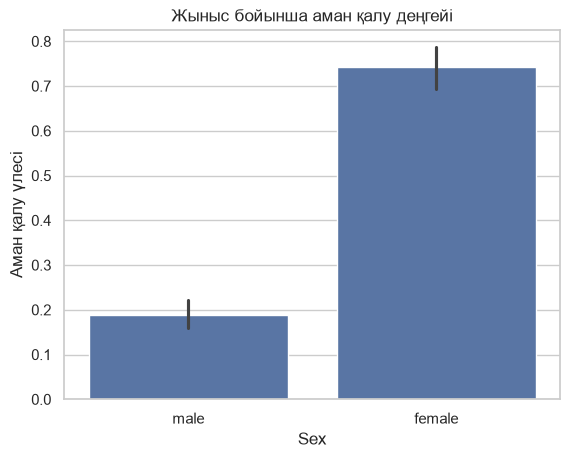

In [38]:
# Жыныс бойынша аман қалу деңгейі (блок дайын)
sns.barplot(data=train, x='Sex', y='Survived')
plt.title('Жыныс бойынша аман қалу деңгейі')
plt.ylabel('Аман қалу үлесі')
plt.show()

Тапсырма: билет класы бойынша аман қалу деңгейін бағаналы диаграммамен көрсетіңіз. Бос орынға қажетті баған атауын жазыңыз.

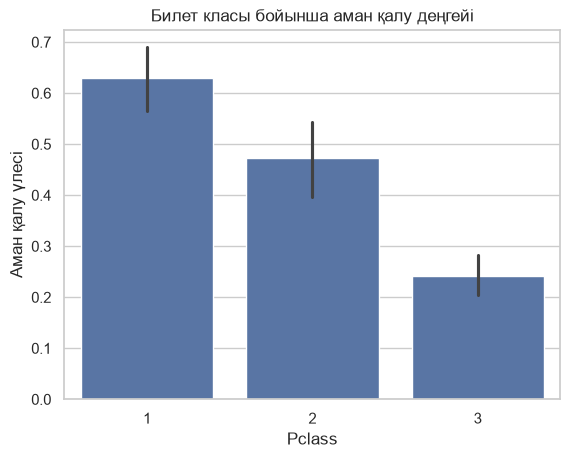

In [39]:
# Бос орынға баған атауын жазыңыз (нұсқау: 'Pclass')
sns.barplot(data=train, x='Pclass', y='Survived')
plt.title('Билет класы бойынша аман қалу деңгейі')
plt.ylabel('Аман қалу үлесі')
plt.show()

## Деректерді алдын ала өңдеу

Мақсаты: бос мәндерді толтыру және мәтіндік белгілерді сандық пішімге келтіру. Нейрондық желі тек сандық деректермен жұмыс істейді, сондықтан бұл кезең міндетті.

Тапсырма: `Age` бағанының бос мәндерін медианамен толтырыңыз. Бос орынға медиананы есептейтін әдіс атауын жазыңыз.

In [40]:
# Бос орынға медиананы есептейтін әдісті жазыңыз (нұсқау: median)
for df in [train, test]:
    df['Age'] = df['Age'].fillna(df['Age'].median())

# Embarked және Fare бағандарын толтыру (блок дайын)
most_common_port = train['Embarked'].mode()[0]
for df in [train, test]:
    df['Embarked'] = df['Embarked'].fillna(most_common_port)
test['Fare'] = test['Fare'].fillna(test['Fare'].median())

print('Бос мәндер толтырылды.')

Бос мәндер толтырылды.


Тапсырма: `Sex` бағанын сандық түрге аударыңыз. Бос орынға сөздіктің мәндерін жазыңыз: `male` мәні 0-ге, `female` мәні 1-ге сәйкес келуі керек.

In [41]:
# Бос орындарға сандық мәндерді жазыңыз (нұсқау: 0 және 1)
for df in [train, test]:
    df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
    df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

print('Категориялық белгілер сандық түрге келтірілді.')

Категориялық белгілер сандық түрге келтірілді.


In [42]:
for df in [train, test]:
    df['Title'] = df['Name'].str.extract(r',\s*([^\.]+)\.')
    df['Title'] = df['Title'].replace(
        ['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona'], 'Rare'
    )
    df['Title'] = df['Title'].replace({'Mlle':'Miss','Ms':'Miss','Mme':'Mrs'})
    df['Title'] = df['Title'].map({'Mr':0,'Miss':1,'Mrs':2,'Master':3,'Rare':4}).fillna(4)

    df['Deck'] = df['Cabin'].str[0].fillna('U')
    df['Deck'] = df['Deck'].map({'U':0,'A':1,'B':2,'C':3,'D':4,'E':5,'F':6,'G':7,'T':8}).fillna(0)


## Жаңа белгілер құрастыру

Мақсаты: бар деректерден модель сапасын арттыруы мүмкін жаңа белгілер жасау. Бұл үдеріс feature engineering деп аталады.

Тапсырма: отбасы мүшелерінің жалпы санын есептейтін `FamilySize` белгісін толтырыңыз. Бос орындарға қосылатын баған атауларын жазыңыз.

In [43]:
# Бос орындарға баған атауларын жазыңыз (нұсқау: 'SibSp' және 'Parch')
for df in [train, test]:
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

train[['SibSp', 'Parch', 'FamilySize', 'IsAlone']].head()

,SibSp,Parch,FamilySize,IsAlone
0,1,0,2,0
1,1,0,2,0
2,0,0,1,1
3,1,0,2,0
4,0,0,1,1


## Деректерді бөлу және масштабтау

Мақсаты: модельге берілетін белгілерді таңдап, деректерді оқыту мен тексеру жиындарына бөлу, содан соң белгілерді бірыңғай масштабқа келтіру. Нейрондық желі үшін масштабтау маңызды, себебі ол белгілердің мәндері жақын ауқымда болғанда тиімдірек оқиды.

Тапсырма: деректерді бөлу үшін `train_test_split` функциясының параметрлерін толтырыңыз. Тексеруге деректердің 20 пайызын бөліңіз (`test_size`) және нәтиже қайталанатын болуы үшін `random_state` мәнін 42 етіп қойыңыз.

In [44]:
features = ['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'Title', 'Deck']
X = train[features]
y = train['Survived']

# Бос орындарға параметр мәндерін жазыңыз (нұсқау: 0.2 және 42)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.5, random_state=42
)

print('Оқыту жиыны:', X_train.shape)
print('Тексеру жиыны:', X_val.shape)

Оқыту жиыны: (445, 9)
Тексеру жиыны: (446, 9)


Тапсырма: белгілерді масштабтаңыз. Бос орынға масштабтаушы құралдың класс атауын жазыңыз.

In [45]:
# Бос орынға класс атауын жазыңыз (нұсқау: StandardScaler)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print('Белгілер масштабталды.')

Белгілер масштабталды.


## Нейрондық желіні құрып оқыту

Мақсаты: көп қабатты нейрондық желі құрып, оны оқыту жиынында оқыту. Біз `MLPClassifier` класын қолданамыз. `hidden_layer_sizes` параметрі жасырын қабаттардағы нейрондар санын анықтайды, ал `activation` активация функциясын белгілейді.

Тапсырма: жасырын қабаттардың өлшемін `(16, 8)` етіп, активация функциясын `relu` етіп толтырыңыз.

In [46]:
# Бос орындарға мәндерді жазыңыз (нұсқау: (16, 8) және 'relu')
model = MLPClassifier(
    hidden_layer_sizes=(16,),
    activation='relu',
    alpha=0.01,
    max_iter=1000,
    random_state=42
)


# Модельді масштабталған оқыту деректерінде оқытамыз
# Бос орындарға оқыту деректерін жазыңыз (нұсқау: X_train_scaled, y_train)
model.fit(X_train_scaled, y_train)

print('Нейрондық желі оқытылды.')

Нейрондық желі оқытылды.


## Модельді бағалау

Мақсаты: модельдің тексеру жиынындағы дәлдігін есептеу және қателер матрицасы арқылы болжам сапасын талдау.

Тапсырма: дәлдікті есептеңіз. Бос орынға дәлдікті есептейтін функция атауын жазыңыз.

In [48]:
val_predictions = model.predict(X_val_scaled)

# Бос орынға дәлдікті есептейтін функция атауын жазыңыз (нұсқау: accuracy_score)
accuracy = accuracy_score(y_val, val_predictions)

print('Тексеру жиынындағы дәлдік:', round(accuracy, 4))

Тексеру жиынындағы дәлдік: 0.8184


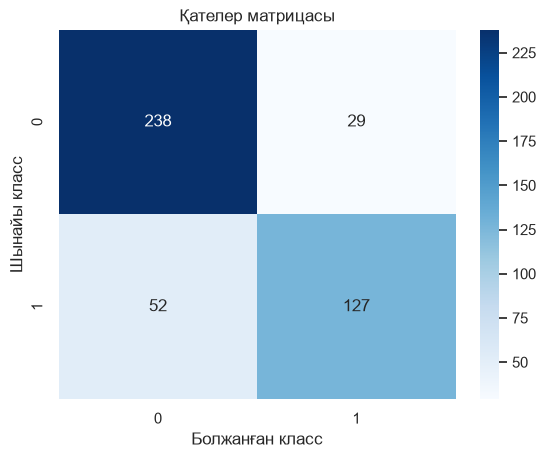

              precision    recall  f1-score   support

           0       0.82      0.89      0.85       267
           1       0.81      0.71      0.76       179

    accuracy                           0.82       446
   macro avg       0.82      0.80      0.81       446
weighted avg       0.82      0.82      0.82       446



In [49]:
# Қателер матрицасы (блок дайын)
cm = confusion_matrix(y_val, val_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Қателер матрицасы')
plt.xlabel('Болжанған класс')
plt.ylabel('Шынайы класс')
plt.show()

print(classification_report(y_val, val_predictions))

## Тест деректері бойынша болжам жасау

Мақсаты: оқытылған нейрондық желіні тест жиынына қолданып, әр жолаушының аман қалу болжамын алу. Тест деректерін де дәл сол масштабтаушымен түрлендіру керек.

Тапсырма: тест белгілерін масштабтап, болжам жасаңыз. Бос орындарды толтырыңыз.

In [50]:
# Бос орынға масштабтайтын әдісті жазыңыз (нұсқау: transform)
X_test_scaled = scaler.transform(test[features])

# Бос орынға болжам жасайтын әдісті жазыңыз (нұсқау: predict)
test_predictions = model.predict(X_test_scaled)

print('Болжам жасалды. Болжамдар саны:', len(test_predictions))

Болжам жасалды. Болжамдар саны: 418


## Нәтижені Kaggle форматында сақтау

Мақсаты: болжамдарды Kaggle жарысы талап ететін пішімде pandas DataFrame ретінде құрастырып, `submission.csv` файлына сақтау. Файлда екі баған болуы керек: `PassengerId` және `Survived`.

Тапсырма: DataFrame құрыңыз. `PassengerId` бағаны тест жиынынан, ал `Survived` бағаны болжамдардан тұруы керек. Бос орындарды толтырыңыз.

In [52]:
# Бос орындарға мәндерді жазыңыз (нұсқау: test['PassengerId'] және test_predictions)
submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived': test_predictions
})

submission.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


Тапсырма: нәтижені CSV файлына сақтаңыз. Бос орынға DataFrame-ді CSV-ге сақтайтын әдіс атауын жазыңыз.

In [53]:
# Бос орынға сақтау әдісінің атауын жазыңыз (нұсқау: to_csv)
submission.to_csv('submission.csv', index=False)

print('submission.csv файлы сәтті сақталды.')

submission.csv файлы сәтті сақталды.


## Қорытынды

Бұл тапсырмада сіз машиналық оқытудың толық жұмыс ағынын орындадыңыз. Деректерді жүктеуден бастап, оларды талдап, өңдеп, жаңа белгілер құрып, нейрондық желі оқытып, нәтижені бағалап, ақыр соңында Kaggle форматындағы файл дайындадыңыз.

Білімді тереңдету үшін келесі қадамдарды өз бетіңізше орындап көріңіз:

- Жасырын қабаттардағы нейрондар санын өзгертіп, дәлдікке әсерін бақылаңыз
- Активация функциясын ауыстырып көріңіз
- Жаңа белгілер қосып, олардың нәтижеге әсерін тексеріңіз